In [15]:
%load_ext autoreload
%autoreload 2

import sys
import os

# Add the parent directory (project root) to sys.path
sys.path.append(os.path.abspath(".."))

# Now import the functions from src.data_prep
from src.data_prep import (
    load_data,
    inspect_data,
    feature_engineering,
    split_data,
    scale_data
)

In [ ]:
# 1. Load Data

df = load_data(r"C:\Users\QMS\creditcard.csv")

# 2. Inspect Data
inspect_data(df)

# 3. Feature Engineering
df_featured = feature_engineering(df)

# 4. Split Data
X_train, X_test, y_train, y_test = split_data(df_featured, target_column='Class')

# 5. Scale Features (Adding 'Time' here)
scaled_cols = ['Amount', 'Time'] 
X_train_scaled, X_test_scaled, scaler = scale_data(X_train, X_test, columns_to_scale=scaled_cols)

CSV data loaded successfully with shape: (284807, 31)
--- FIRST 5 ROWS ---
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  

### Step 2: Exploratory data analysis:
#### This section seeks to tell the story of the data looking at the following: Class distribution plot, Percentage of fraud vs non-fraud, Correlation heatmap, etc.

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

#Setting the visual style for all plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

Legitimate Transactions: 284315 (99.8273%)
Fraudulent Transactions: 492 (0.1727%)


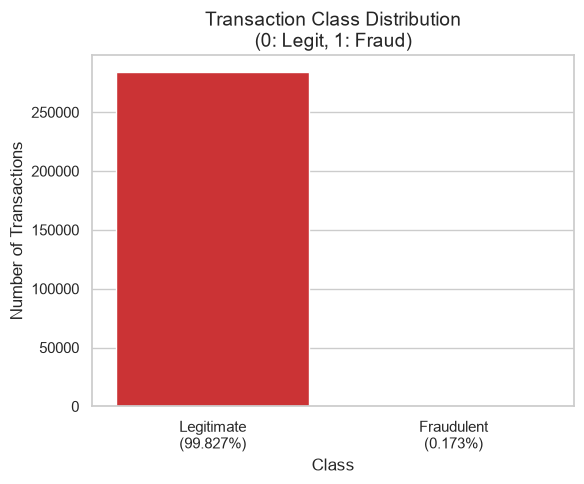

In [6]:
#Calculating percentages
fraud_counts = df['Class'].value_counts()
total_records = len(df)
pct_legit = (fraud_counts[0]/total_records) * 100
pct_fraud = (fraud_counts[1]/total_records) * 100

print(f"Legitimate Transactions: {fraud_counts[0]} ({pct_legit:.4f}%)")
print(f"Fraudulent Transactions: {fraud_counts[1]} ({pct_fraud:.4f}%)")

#Plot Class Distribution
plt.figure(figsize=(6, 5))
sns.countplot(x='Class', data=df, hue='Class', palette='Set1', legend=False)
plt.title('Transaction Class Distribution\n(0: Legit, 1: Fraud)', fontsize=14)
plt.xlabel('Class')
plt.ylabel('Number of Transactions')
plt.xticks([0, 1], [f'Legitimate\n({pct_legit:.3f}%)', f'Fraudulent\n({pct_fraud:.3f}%)'])
plt.tight_layout()
plt.show()

#### Plot Horizontal Class Distribution with Log Scale

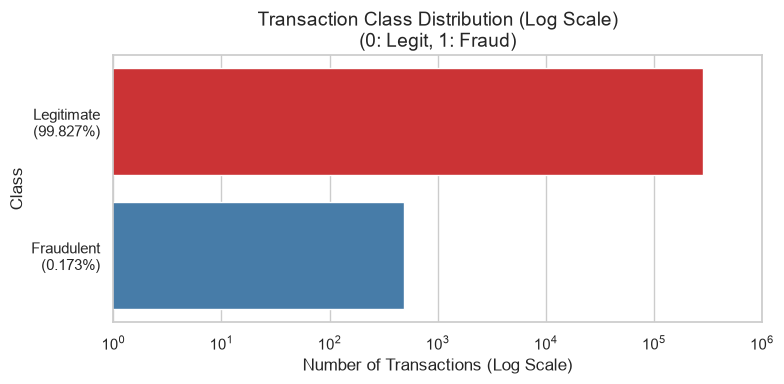

In [7]:
plt.figure(figsize=(8, 4))

# Horizontal plot using y='Class'
sns.countplot(y='Class', data=df, hue='Class', palette='Set1', legend=False)

# Logarithmic scale makes the rare fraud bar clearly visible
plt.xscale('log')

# Optional: set limits to give the logarithmic axis clean padding
plt.xlim(1, 10**6)

plt.title('Transaction Class Distribution (Log Scale)\n(0: Legit, 1: Fraud)', fontsize=14)
plt.ylabel('Class', fontsize=12)
plt.xlabel('Number of Transactions (Log Scale)', fontsize=12)
plt.yticks([0, 1], [f'Legitimate\n({pct_legit:.3f}%)', f'Fraudulent\n({pct_fraud:.3f}%)'])

plt.tight_layout()
plt.show()

#### Computing correlation matrix

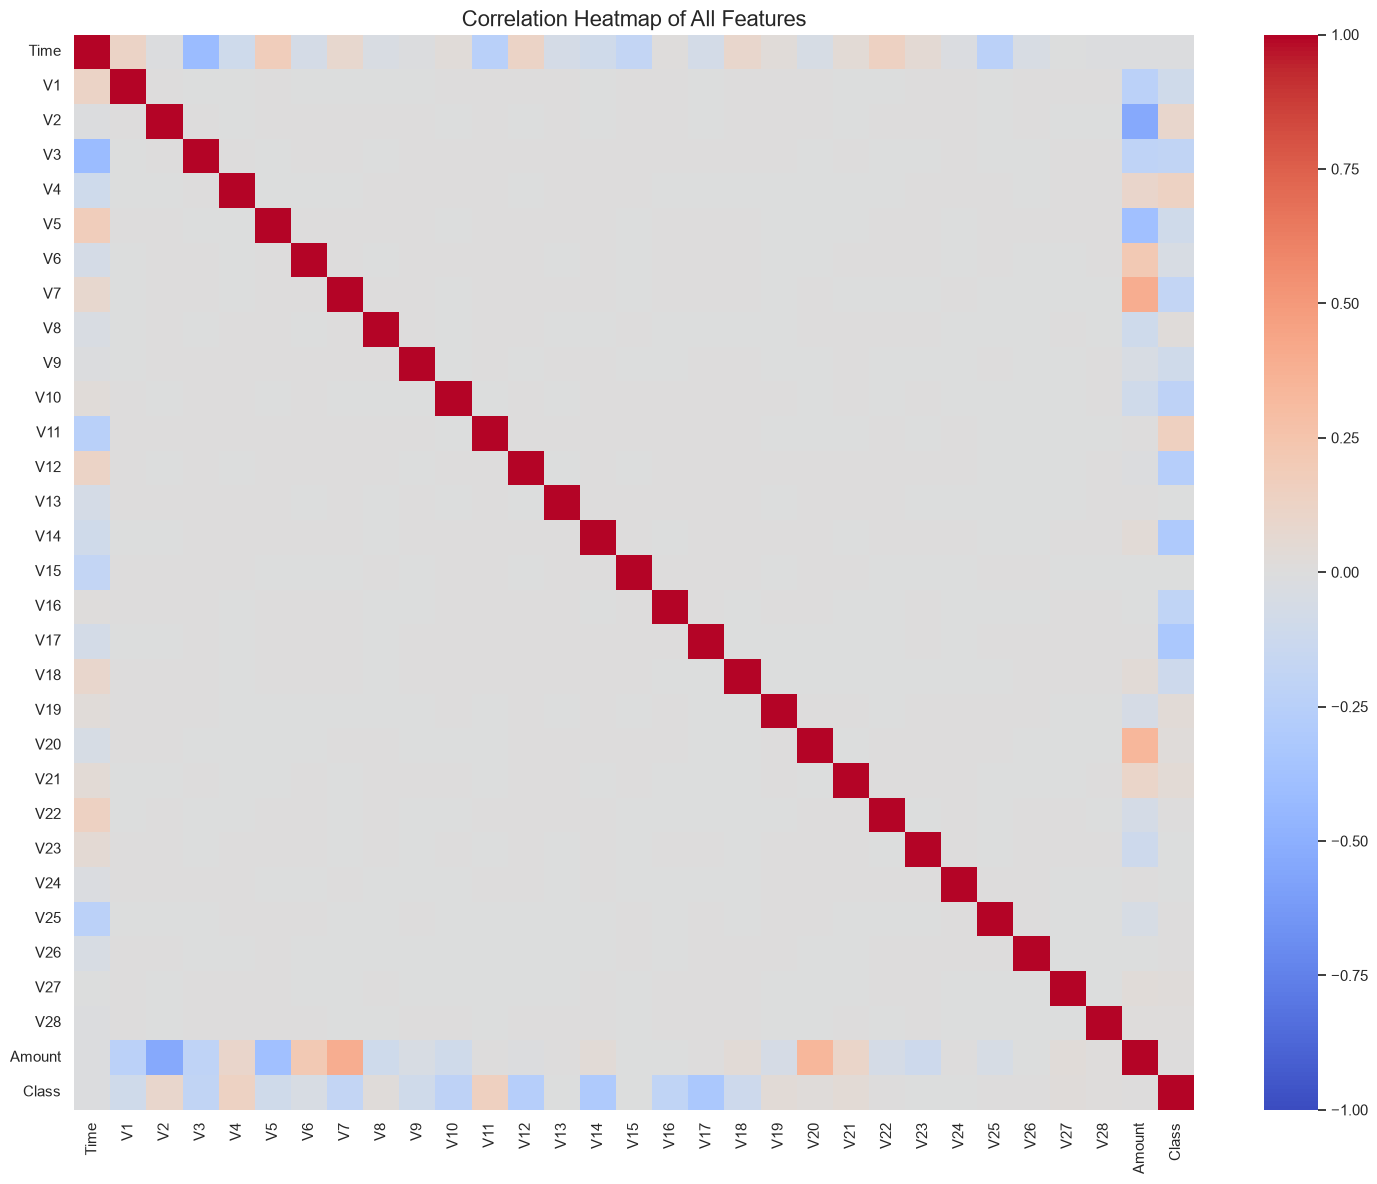

In [8]:
corr_matrix = df.corr()

plt.figure(figsize=(15, 12))
# Using a diverging coolwarm palette to clearly show positive (red) and negative (blue) correlations
sns.heatmap(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, annot=False, fmt=".2f")
plt.title('Correlation Heatmap of All Features', fontsize=16)
plt.tight_layout()
plt.show()

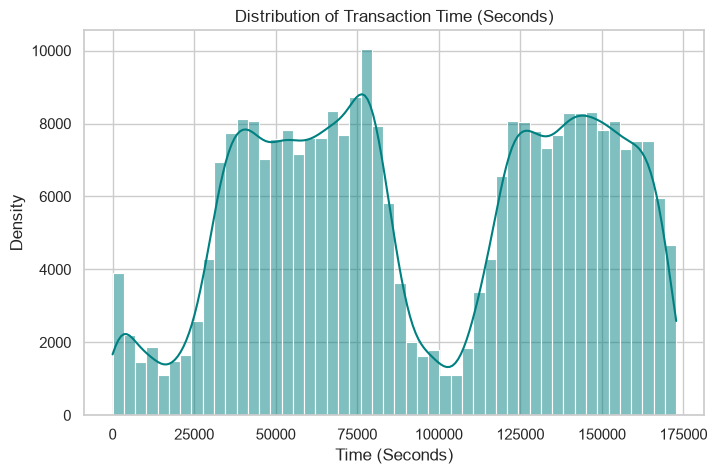

In [9]:
# Set up a single plot
plt.figure(figsize=(8, 5))

# Plot without referencing an undefined 'axes' variable
sns.histplot(df['Time'], bins=50, kde=True, color='teal')
plt.title('Distribution of Transaction Time (Seconds)')
plt.xlabel('Time (Seconds)')
plt.ylabel('Density')
plt.show()

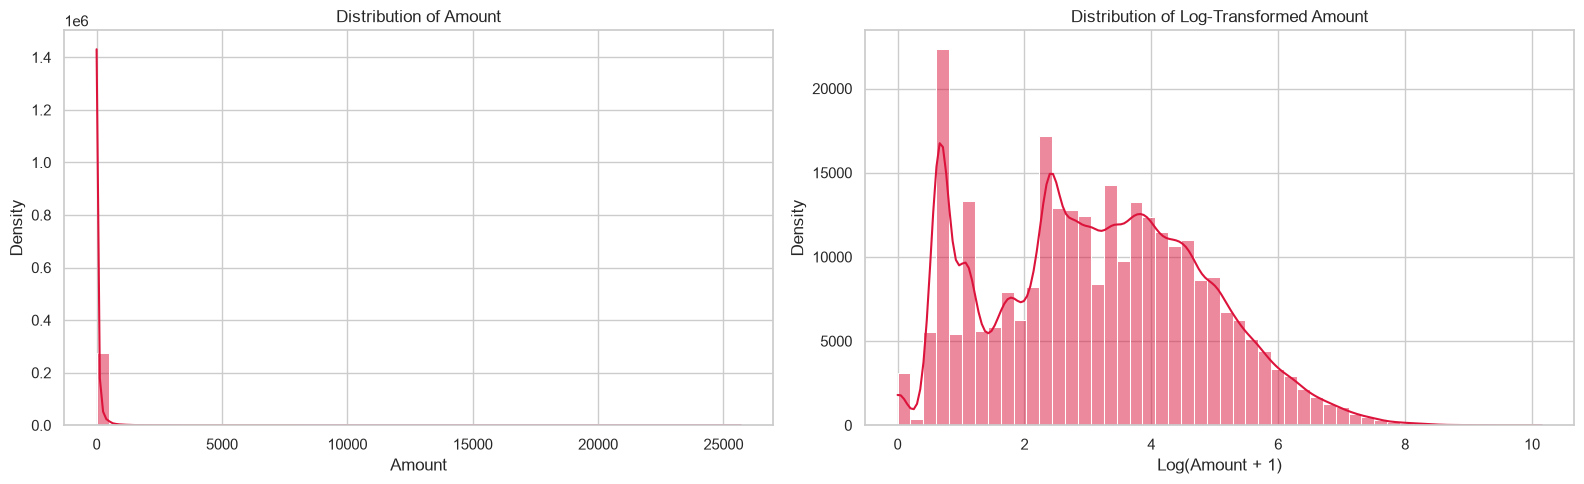

In [12]:
# Set up a 1x2 subplot grid
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Raw Amount Distribution (Left Plot - axes[0])
sns.histplot(df['Amount'], bins=50, kde=True, ax=axes[0], color='crimson')
axes[0].set_title('Distribution of Amount')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Density')

# Plot 2: Log-Transformed Amount Distribution (Right Plot - axes[1])
sns.histplot(np.log1p(df['Amount']), bins=50, kde=True, ax=axes[1], color='crimson')
axes[1].set_title('Distribution of Log-Transformed Amount')
axes[1].set_xlabel('Log(Amount + 1)')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.show()

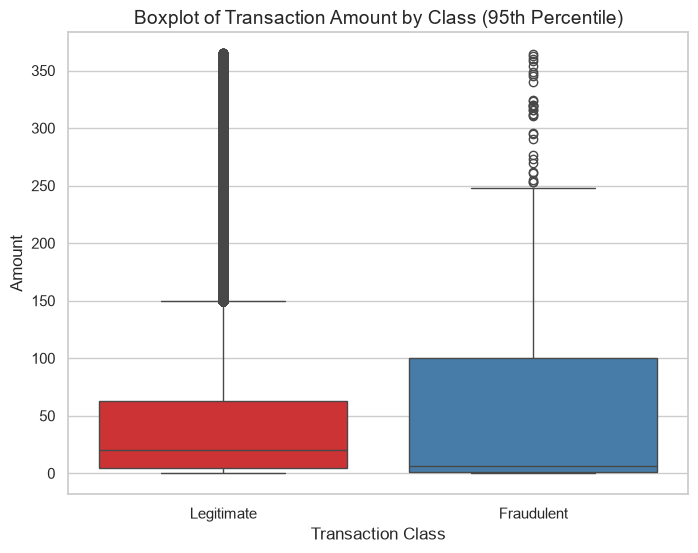

In [13]:
plt.figure(figsize=(8, 6))
# Zooming in on transactions up to the 95th percentile to keep the box visible (ignoring extreme outliers)
sns.boxplot(x='Class', y='Amount', data=df[df['Amount'] < df['Amount'].quantile(0.95)], hue='Class', palette='Set1', legend=False)
plt.title('Boxplot of Transaction Amount by Class (95th Percentile)', fontsize=14)
plt.xticks([0, 1], ['Legitimate', 'Fraudulent'])
plt.xlabel('Transaction Class')
plt.ylabel('Amount')
plt.show()

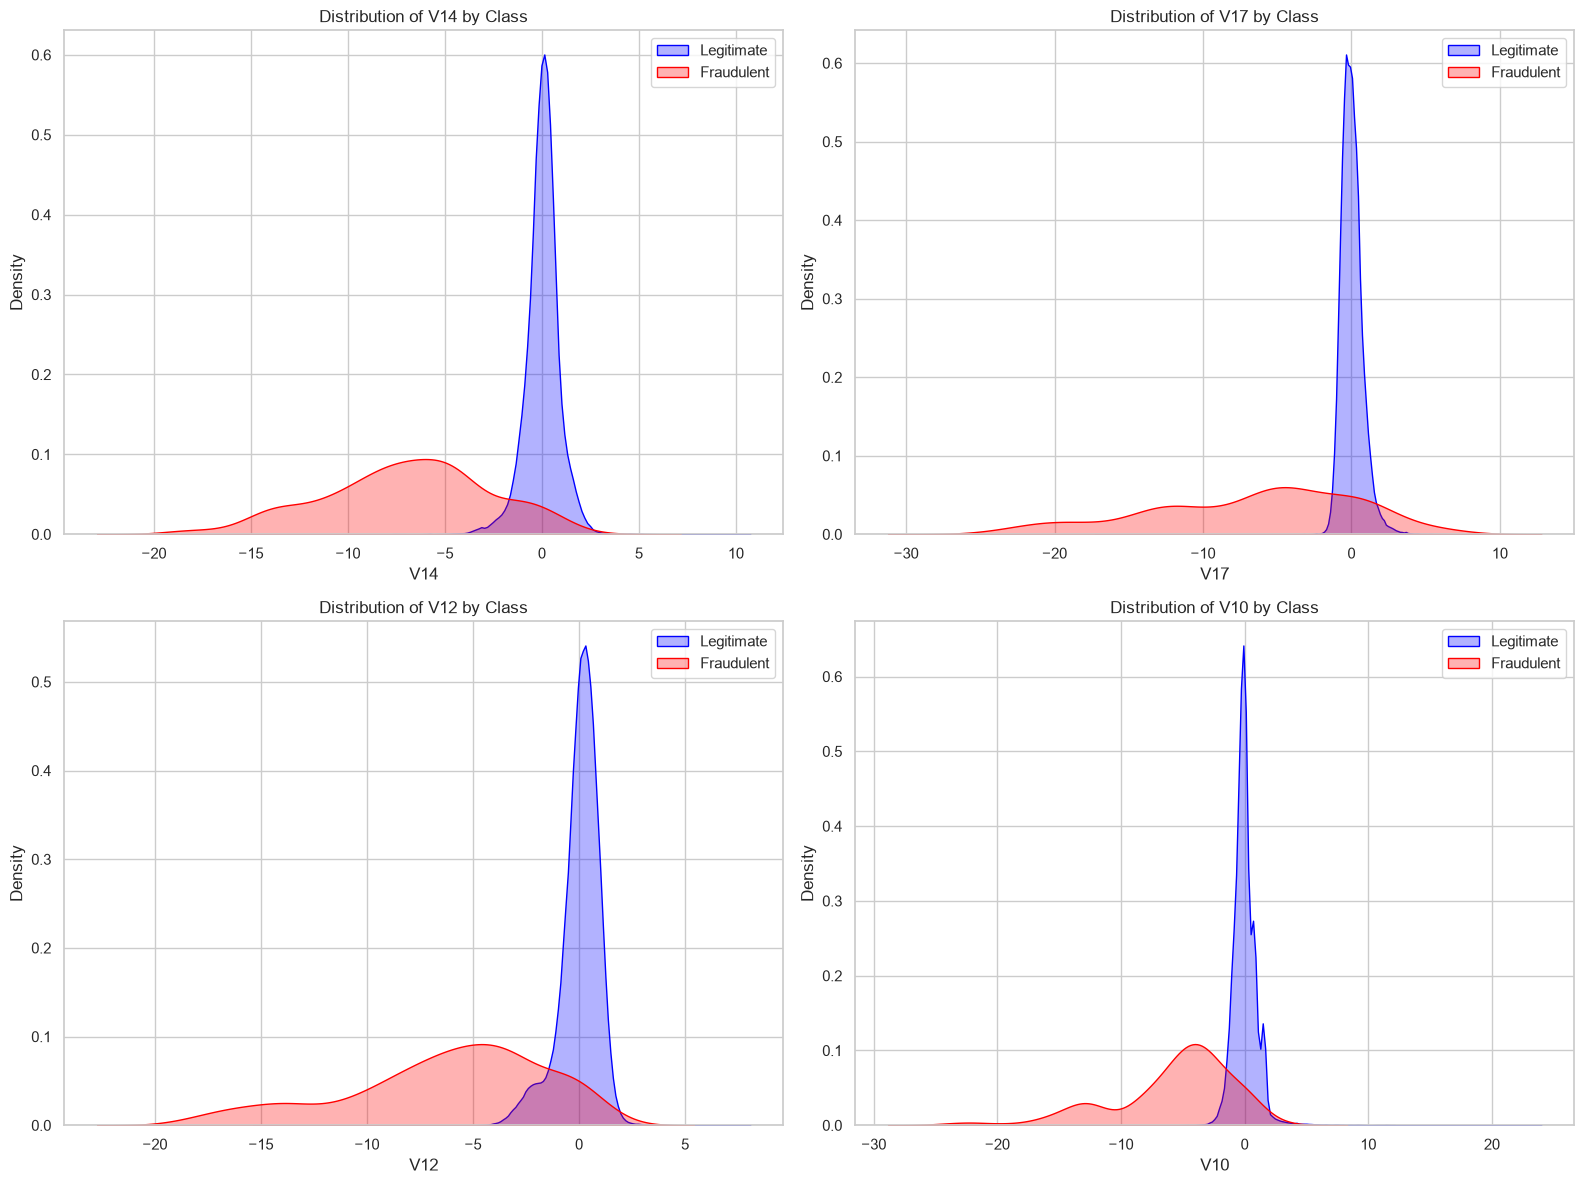

In [14]:
# Let's select four features that typically correlate strongly with class (V14, V17, V12, V10)
selected_vars = ['V14', 'V17', 'V12', 'V10']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(selected_vars):
    sns.kdeplot(df[df['Class'] == 0][col], label='Legitimate', fill=True, color='blue', alpha=0.3, ax=axes[i])
    sns.kdeplot(df[df['Class'] == 1][col], label='Fraudulent', fill=True, color='red', alpha=0.3, ax=axes[i])
    axes[i].set_title(f'Distribution of {col} by Class')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].legend()

plt.tight_layout()
plt.show()

### Addressing the class imbalance

In [4]:
# Import sampling / weighting functions
from src.sampling import get_class_weights

# 2. Compute Class Weights for Imbalanced Data
class_weights = get_class_weights(y_train)

[INFO] Computed Class Weights: {np.int64(0): np.float64(0.5008661206149896), np.int64(1): np.float64(289.14340101522845)}
